In [1]:
# Import core libraries

import pandas as pd
import numpy as np

# Import visualisation libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Import text classifiers
import re
import nltk
import string

# warnings
import warnings
warnings.filterwarnings("ignore")


Data loading

In [176]:
df = pd.read_csv("../data/Customer insight review.csv")

In [ ]:
df.head(5)

In [6]:
# Make a working copy

df_copy = df.copy()

In [7]:
df_copy.head(5)

,Timestamp,Email Address,Do you own a wireless speaker?,How often do you use your wireless speaker?,How would you rate the sound quality of your wireless speaker?,explain the rating,How important is sound quality,How important is battery life,how important is design/Looks,"how important is connectivity options (e.g., Bluetooth, Wi-Fi)",...,Have any other lifestyle changes in the past year changed how you use wireless speakers?,How much did you spend on your wireless speaker? (US dollars),How likely are you to buy a new wireless speaker in the next 12 months?,Where do you like to buy wireless speakers?,How do you think about and evaluate the price when buying a wireless speaker?,How old are you?,What is your gender?,What's your annual household income?,"Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.",Score
0,7/15/2024 0:17:17,fedenakashima@gmail.com,Yes,Daily,Excellent,I think it is excellent because I have nothing...,1.0,3.0,4.0,5.0,...,"More media consumption (music, movies, games)",Less than $50,1.0,"Large multi-brand stores (e.g., Amazon)",I compare it to weather it is a better option ...,18-24,Female,"More than $100,000",-,NaN
1,7/15/2024 0:21:44,victor3flores@yahoo.com,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7/15/2024 0:38:00,joycipaluz@gmail.com,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7/15/2024 21:59:16,kandacelipscomb4@gmail.com,Yes,Once a week,Good,"It’s kinda staticky, but it gets the job done (:",4.0,1.0,3.0,5.0,...,"Spending more time at home, Home workouts",$50 to $100,3.0,"Large multi-brand stores (e.g., Amazon)",I tend to go cheaper,18-24,Female,"$25,000-$50,000",NaN,NaN
4,7/15/2024 21:59:47,lailaball1@icloud.com,Yes,Daily,Excellent,It’s a Bose and it’s the best,6.0,4.0,2.0,5.0,...,"More media consumption (music, movies, games)",$100 to $200,2.0,"Large multi-brand stores (e.g., Amazon)",Usage,18-24,Female,"$50,000-$75,000",Na,NaN


In [9]:
# Filter out to respondents that do not own a wireless speaker.

df_copy['Do you own a wireless speaker?'].value_counts()

Do you own a wireless speaker?
Yes    3604
No     1466
Name: count, dtype: int64

Out of 5,070 respondents, approximately 71% reported owning a wireless speaker, indicating strong market penetration for wireless audio devices among surveyed consumers.

In [10]:
df_users = df_copy[df_copy['Do you own a wireless speaker?'] == 'Yes']

In [11]:
df_users.head(2)

,Timestamp,Email Address,Do you own a wireless speaker?,How often do you use your wireless speaker?,How would you rate the sound quality of your wireless speaker?,explain the rating,How important is sound quality,How important is battery life,how important is design/Looks,"how important is connectivity options (e.g., Bluetooth, Wi-Fi)",...,Have any other lifestyle changes in the past year changed how you use wireless speakers?,How much did you spend on your wireless speaker? (US dollars),How likely are you to buy a new wireless speaker in the next 12 months?,Where do you like to buy wireless speakers?,How do you think about and evaluate the price when buying a wireless speaker?,How old are you?,What is your gender?,What's your annual household income?,"Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.",Score
0,7/15/2024 0:17:17,fedenakashima@gmail.com,Yes,Daily,Excellent,I think it is excellent because I have nothing...,1.0,3.0,4.0,5.0,...,"More media consumption (music, movies, games)",Less than $50,1.0,"Large multi-brand stores (e.g., Amazon)",I compare it to weather it is a better option ...,18-24,Female,"More than $100,000",-,NaN
3,7/15/2024 21:59:16,kandacelipscomb4@gmail.com,Yes,Once a week,Good,"It’s kinda staticky, but it gets the job done (:",4.0,1.0,3.0,5.0,...,"Spending more time at home, Home workouts",$50 to $100,3.0,"Large multi-brand stores (e.g., Amazon)",I tend to go cheaper,18-24,Female,"$25,000-$50,000",NaN,NaN


In [12]:
df_users.columns

Index(['Timestamp', 'Email Address', 'Do you own a wireless speaker?',
       'How often do you use your wireless speaker?',
       'How would you rate the sound quality of your wireless speaker?',
       'explain the rating', 'How important is sound quality',
       'How important is battery life', 'how important is design/Looks',
       'how important is connectivity options (e.g., Bluetooth, Wi-Fi)',
       'how important is durability', 'how important is price',
       'what brand do you own',
       'What made you buy your current wireless speaker? Recommendation from friends/family',
       'What made you buy your current wireless speaker? Online reviews from other customers ',
       'What made you buy your current wireless speaker? Expert reviews',
       'What made you buy your current wireless speaker? Brand reputation',
       'What made you buy your current wireless speaker? Price',
       'What made you buy your current wireless speaker? Specific features',
       'What ma

In [13]:
# Rename the columns

df_users = df_users.rename(columns={
'Do you own a wireless speaker?':'owns_speaker',
'How often do you use your wireless speaker?':'usage_frequency',
'How would you rate the sound quality of your wireless speaker?':'sound_quality_rating',
'explain the rating':'sound_quality_comment',
'How important is sound quality':'importance_sound_quality',
'How important is battery life':'importance_battery_life',
'how important is design/Looks':'importance_design',
'how important is connectivity options (e.g., Bluetooth, Wi-Fi)':'importance_connectivity',
'how important is durability':'importance_durability',
'how important is price':'importance_price',
'what brand do you own':'owned_brand',
'What made you buy your current wireless speaker? Recommendation from friends/family':'purchase_driver_recommendation',
'What made you buy your current wireless speaker? Online reviews from other customers ':'purchase_driver_online_reviews',
'What made you buy your current wireless speaker? Expert reviews':'purchase_driver_expert_reviews',
'What made you buy your current wireless speaker? Brand reputation':'purchase_driver_brand_reputation',
'What made you buy your current wireless speaker? Price':'purchase_driver_price',
'What made you buy your current wireless speaker? Specific features':'purchase_driver_features',
'What made you buy your current wireless speaker? Advertising':'purchase_driver_advertising',
'How happy are you with your wireless speaker?':'overall_satisfaction',
'What would make your wireless speaker better?':'improvement_suggestions',
'What do you mostly use your wireless speaker for? ':'primary_usage',
'Have any other lifestyle changes in the past year changed how you use wireless speakers? ':'lifestyle_changes_usage',
'How much did you spend on your wireless speaker? (US dollars)':'price_paid',
'How likely are you to buy a new wireless speaker in the next 12 months?':'purchase_intent',
'Where do you like to buy wireless speakers?':'purchase_channel',
'How do you think about and evaluate the price when buying a wireless speaker? ':'price_evaluation',
'How old are you?':'age',
'What is your gender?':'gender',
"What's your annual household income?":'income',
'Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.':'additional_feedback'
})

In [14]:
df_users.columns

Index(['Timestamp', 'Email Address', 'owns_speaker', 'usage_frequency',
       'sound_quality_rating', 'sound_quality_comment',
       'importance_sound_quality', 'importance_battery_life',
       'importance_design', 'importance_connectivity', 'importance_durability',
       'importance_price', 'owned_brand', 'purchase_driver_recommendation',
       'purchase_driver_online_reviews', 'purchase_driver_expert_reviews',
       'purchase_driver_brand_reputation', 'purchase_driver_price',
       'purchase_driver_features', 'purchase_driver_advertising',
       'overall_satisfaction', 'improvement_suggestions', 'primary_usage',
       'lifestyle_changes_usage', 'price_paid', 'purchase_intent',
       'purchase_channel', 'price_evaluation', 'age', 'gender', 'income',
       'additional_feedback', 'Score'],
      dtype='str')

Data profiling & validation


In [20]:
df_users.shape

(3604, 33)

In [15]:
df_users.info()

<class 'pandas.DataFrame'>
Index: 3604 entries, 0 to 5069
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Timestamp                         3604 non-null   str    
 1   Email Address                     3604 non-null   str    
 2   owns_speaker                      3604 non-null   str    
 3   usage_frequency                   3604 non-null   str    
 4   sound_quality_rating              3604 non-null   str    
 5   sound_quality_comment             3586 non-null   str    
 6   importance_sound_quality          3604 non-null   float64
 7   importance_battery_life           3604 non-null   float64
 8   importance_design                 3604 non-null   float64
 9   importance_connectivity           3604 non-null   float64
 10  importance_durability             3604 non-null   float64
 11  importance_price                  3604 non-null   float64
 12  owned_brand           

In [17]:
df_users.describe().T

,count,mean,std,min,25%,50%,75%,max
importance_sound_quality,3604.0,3.427303,2.142052,1.0,1.0,3.0,6.0,6.0
importance_battery_life,3604.0,3.534129,1.413900,1.0,2.0,4.0,5.0,6.0
importance_design,3604.0,3.487791,1.823648,1.0,2.0,3.0,5.0,6.0
importance_connectivity,3604.0,3.534406,1.389938,1.0,3.0,4.0,4.0,6.0
importance_durability,3604.0,3.459212,1.483278,1.0,2.0,3.0,5.0,6.0
importance_price,3604.0,3.578524,1.845758,1.0,2.0,4.0,5.0,6.0
overall_satisfaction,3604.0,4.051332,0.934060,1.0,4.0,4.0,5.0,5.0
purchase_intent,3604.0,2.374584,1.316889,1.0,1.0,2.0,3.0,5.0


In [18]:
df_users.describe(include='object').T

,count,unique,top,freq
Timestamp,3604,3548,09/10/2024 6:37,3
Email Address,3604,3576,nuroag186@gmail.com,3
owns_speaker,3604,1,Yes,3604
usage_frequency,3604,5,Several times a week,1223
sound_quality_rating,3604,5,Good,1825
sound_quality_comment,3586,3217,Good,47
owned_brand,3602,683,JBL,970
purchase_driver_recommendation,3604,5,"3 (Important, but not a deal breaker)",971
purchase_driver_online_reviews,3604,5,4,989
purchase_driver_expert_reviews,3604,5,5 (Very Important),904


In [19]:
df_users.isnull().sum()

Timestamp                              0
Email Address                          0
owns_speaker                           0
usage_frequency                        0
sound_quality_rating                   0
sound_quality_comment                 18
importance_sound_quality               0
importance_battery_life                0
importance_design                      0
importance_connectivity                0
importance_durability                  0
importance_price                       0
owned_brand                            2
purchase_driver_recommendation         0
purchase_driver_online_reviews         0
purchase_driver_expert_reviews         0
purchase_driver_brand_reputation       0
purchase_driver_price                  0
purchase_driver_features               0
purchase_driver_advertising            0
overall_satisfaction                   0
improvement_suggestions               59
primary_usage                          0
lifestyle_changes_usage               68
price_paid      

In [21]:
duplicates = int(df_users.duplicated().sum())
duplicates

0

In [22]:
df_users.columns

Index(['Timestamp', 'Email Address', 'owns_speaker', 'usage_frequency',
       'sound_quality_rating', 'sound_quality_comment',
       'importance_sound_quality', 'importance_battery_life',
       'importance_design', 'importance_connectivity', 'importance_durability',
       'importance_price', 'owned_brand', 'purchase_driver_recommendation',
       'purchase_driver_online_reviews', 'purchase_driver_expert_reviews',
       'purchase_driver_brand_reputation', 'purchase_driver_price',
       'purchase_driver_features', 'purchase_driver_advertising',
       'overall_satisfaction', 'improvement_suggestions', 'primary_usage',
       'lifestyle_changes_usage', 'price_paid', 'purchase_intent',
       'purchase_channel', 'price_evaluation', 'age', 'gender', 'income',
       'additional_feedback', 'Score'],
      dtype='str')

In [23]:
# Drop columns not relevant to the analysis
df_users = df_users.drop(columns=[
    'Timestamp',
    'Email Address',
    'additional_feedback',
    'Score'
])

In [24]:
df_users.columns

Index(['owns_speaker', 'usage_frequency', 'sound_quality_rating',
       'sound_quality_comment', 'importance_sound_quality',
       'importance_battery_life', 'importance_design',
       'importance_connectivity', 'importance_durability', 'importance_price',
       'owned_brand', 'purchase_driver_recommendation',
       'purchase_driver_online_reviews', 'purchase_driver_expert_reviews',
       'purchase_driver_brand_reputation', 'purchase_driver_price',
       'purchase_driver_features', 'purchase_driver_advertising',
       'overall_satisfaction', 'improvement_suggestions', 'primary_usage',
       'lifestyle_changes_usage', 'price_paid', 'purchase_intent',
       'purchase_channel', 'price_evaluation', 'age', 'gender', 'income'],
      dtype='str')

Exploratory Data Analysis

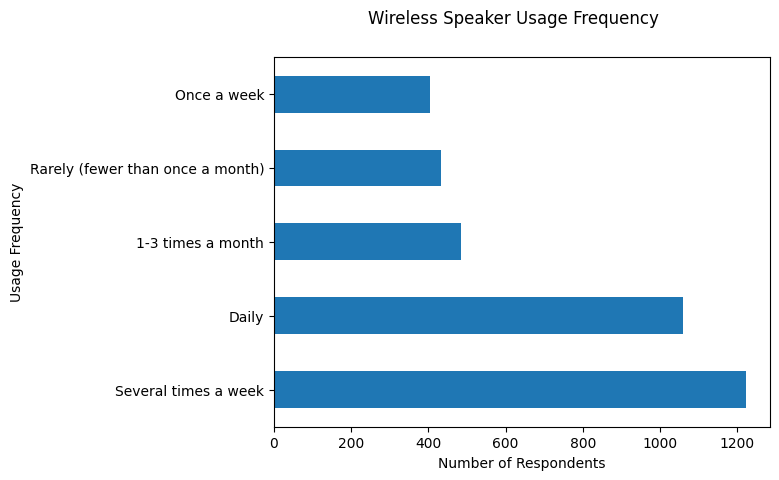

In [33]:
# graph showing usage frequency among wireless speaker owners

df_users['usage_frequency'].value_counts().plot(kind='barh')
plt.ylabel("Usage Frequency")
plt.xlabel("Number of Respondents")
plt.suptitle("Wireless Speaker Usage Frequency");

In [36]:
# what features do owners prioritise?

importance_cols = [
'importance_sound_quality',
'importance_battery_life',
'importance_design',
'importance_connectivity',
'importance_durability',
'importance_price'
]

df_users[importance_cols].mean().sort_values(ascending=False)

importance_price            3.578524
importance_connectivity     3.534406
importance_battery_life     3.534129
importance_design           3.487791
importance_durability       3.459212
importance_sound_quality    3.427303
dtype: float64

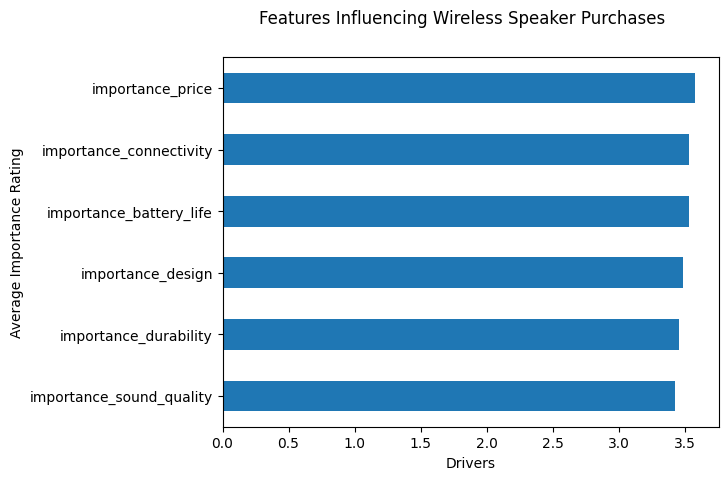

In [45]:
# visualise important factors considered before purchase

importance_drivers = df_users[importance_cols].mean().sort_values(ascending=True)

importance_drivers.plot(kind='barh')
plt.xlabel("Drivers")
plt.ylabel("Average Importance Rating")
plt.suptitle("Features Influencing Wireless Speaker Purchases")
plt.show()

In [ ]:
# Given the survey column contains string, use regex to eliminate the strings.

df_users[purchase_cols] = df_users[purchase_cols].replace(r'^(\d).*', r'\1', regex=True).astype(float)

In [39]:
# What are the purchase drivers

purchase_cols = [
'purchase_driver_recommendation',
'purchase_driver_online_reviews',
'purchase_driver_expert_reviews',
'purchase_driver_brand_reputation',
'purchase_driver_price',
'purchase_driver_features',
'purchase_driver_advertising'
]

df_users[purchase_cols].mean().sort_values(ascending=False)

purchase_driver_price               3.916759
purchase_driver_brand_reputation    3.670644
purchase_driver_features            3.411487
purchase_driver_online_reviews      3.411210
purchase_driver_expert_reviews      3.369867
purchase_driver_recommendation      2.885128
purchase_driver_advertising         2.423696
dtype: float64

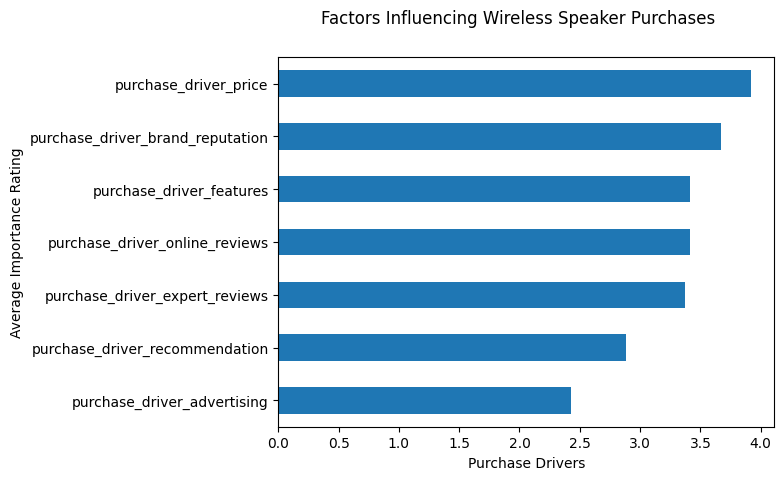

In [43]:
# Visualise the purchase driverss

purchase_drivers = df_users[purchase_cols].mean().sort_values(ascending=True)

purchase_drivers.plot(kind='barh')
plt.xlabel("Purchase Drivers")
plt.ylabel("Average Importance Rating")
plt.suptitle("Factors Influencing Wireless Speaker Purchases")
plt.show()

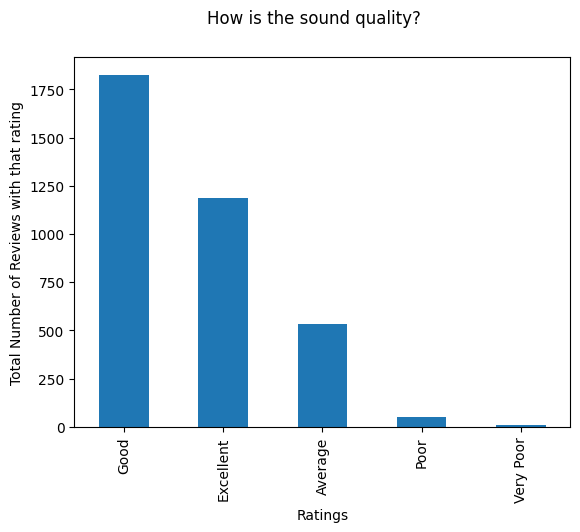

In [52]:
# How satisfied are the owners with the sound quality?

df_users['sound_quality_rating'].value_counts().plot(kind='bar')
plt.ylabel("Total Number of Reviews with that rating")
plt.xlabel("Ratings")
plt.suptitle("How is the sound quality?");

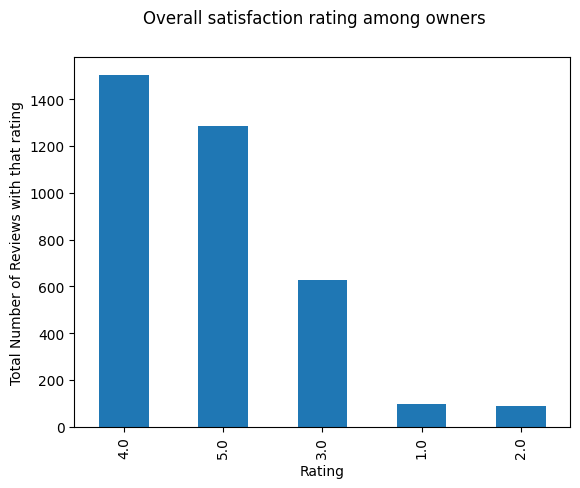

In [54]:
# How satisfied are the owners overall?

df_users["overall_satisfaction"].value_counts().plot(kind = 'bar')
plt.xlabel('Rating')
plt.ylabel('Total Number of Reviews with that rating')
plt.suptitle('Overall satisfaction rating among owners');

In [56]:
# how much do owners spend on wireless speakers?

df_users['price_paid'].value_counts()

price_paid
$50 to $100         1253
Less than $50       1133
$100 to $200         851
$200 to $300         247
- More than $300     117
More than $300         3
Name: count, dtype: int64

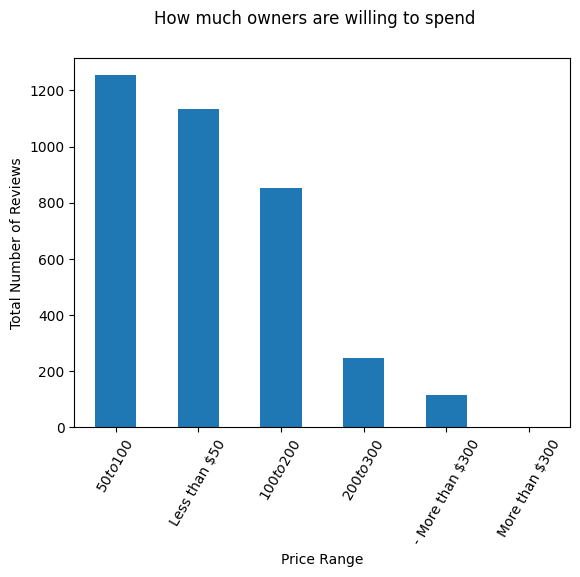

In [75]:
df_users['price_paid'].value_counts().plot(kind = 'bar')
plt.ylabel("Total Number of Reviews")
plt.xlabel("Price Range")
plt.suptitle('How much owners are willing to spend')
plt.xticks(rotation=60);


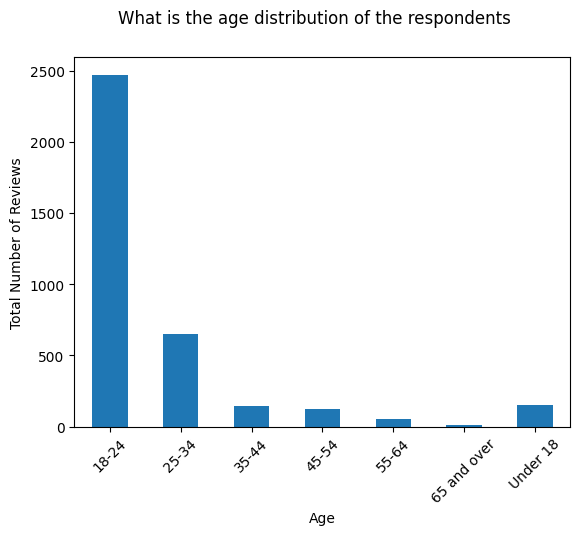

In [76]:
# Who are these owners, what age group are they?

df_users['age'].value_counts().sort_index().plot(kind = 'bar')
plt.ylabel("Total Number of Reviews")
plt.xlabel("Age")
plt.suptitle('What is the age distribution of the respondents')
plt.xticks(rotation=45);

Text Analysis

In [100]:
# import the libraries for text processing

from nltk.corpus import stopwords
from collections import Counter
from nltk.util import ngrams
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download("punkt")
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADACHUKWU\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADACHUKWU\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADACHUKWU\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
# clean text

def clean_text (text):
    if pd.isna(text):
        return ""   # return empty string if null or missing values.

    text = str(text).lower() # converts to string and lower case.
    text = re.sub(r"[^a-z\s]", " ", text) # removes non letter and non space and replace with space.
    text = re.sub(r"\s+", " ", text).strip() # remove trailing white spaces.
    return text  

In [94]:
df_users['clean_text'] = df_users['price_evaluation'].apply(clean_text)

In [103]:
df_users['clean_text']

0       i compare it to weather it is a better option ...
3                                    i tend to go cheaper
4                                                   usage
5       price compared to features sound quality and s...
6       the price should be determined by the size but...
                              ...                        
5064                            the best bang for my buck
5066                                         it s expense
5067             how the volume is and how reliable it is
5068                         compare it to similar brands
5069                                     the battery life
Name: clean_text, Length: 3565, dtype: str

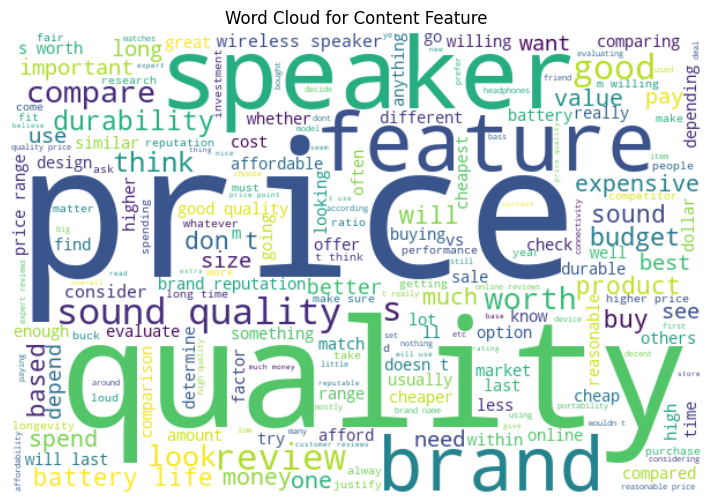

In [106]:
text_cloud = ' '.join(df_users['clean_text'])

wordcloud = WordCloud(width=600, height=400, background_color='white').generate(text_cloud)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Content Feature')
plt.show();

In [96]:
# Tokenise column

def tokenize(text):
    return word_tokenize(text)

In [101]:
df_users['tokens'] = df_users["clean_text"].apply(tokenize)

In [102]:
df_users['tokens']

0       [i, compare, it, to, weather, it, is, a, bette...
3                              [i, tend, to, go, cheaper]
4                                                 [usage]
5       [price, compared, to, features, sound, quality...
6       [the, price, should, be, determined, by, the, ...
                              ...                        
5064                     [the, best, bang, for, my, buck]
5066                                     [it, s, expense]
5067    [how, the, volume, is, and, how, reliable, it,...
5068                   [compare, it, to, similar, brands]
5069                                 [the, battery, life]
Name: tokens, Length: 3565, dtype: object

In [151]:
# create the stopwords list

sw = set(stopwords.words("english"))
stop_keywords = {'think', 'compare', 'similar', 'bang', 'the', 'buying', 'buy', 'one', 
                   'willing', 'weather', 'tend', 'option', 'cheap', 'good', 
                   'worth', 'use', 'speakers', 'look', 'based', 'much', 'spend', 'speaker', 'would', 'expensive'}
custom_stopwords = sw.union(stop_keywords)

In [152]:
# function to remove stopwords

def remove_stopwords(tokens):
    return [word for word in tokens if word not in custom_stopwords]

In [153]:
df_users['clean_tokens'] = df_users['tokens'].apply(remove_stopwords)
df_users['clean_tokens']

0                               [better, computer, sound]
3                                           [go, cheaper]
4                                                 [usage]
5       [price, compared, features, sound, quality, size]
6       [price, determined, size, importantly, quality...
                              ...                        
5064                                         [best, buck]
5066                                            [expense]
5067                                   [volume, reliable]
5068                                             [brands]
5069                                      [battery, life]
Name: clean_tokens, Length: 3565, dtype: object

In [154]:
df_users[["price_evaluation", "clean_tokens"]].head(10)

,price_evaluation,clean_tokens
0,I compare it to weather it is a better option ...,"[better, computer, sound]"
3,I tend to go cheaper,"[go, cheaper]"
4,Usage,[usage]
5,"Price compared to features, sound quality, and...","[price, compared, features, sound, quality, size]"
6,The price should be determined by the size but...,"[price, determined, size, importantly, quality..."
9,A lot,[lot]
10,If it’s over $100 it needs to last me a decade,"[needs, last, decade]"
11,How quality the product is,"[quality, product]"
13,the reviews,[reviews]
14,affordability,[affordability]


Visualise the top recurring keywords

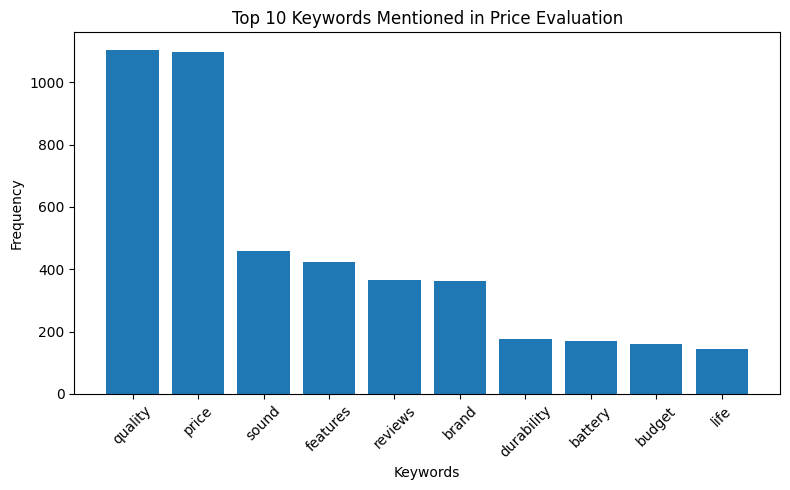

In [155]:
all_words = [word for doc in 
df_users['clean_tokens'] for word in doc]
word_counts = Counter(all_words).most_common(10)

words, counts = zip(*word_counts)

plt.figure(figsize=(8,5))
bars = plt.bar(words, counts)

plt.ylabel("Frequency")
plt.xlabel("Keywords")
plt.title("Top 10 Keywords Mentioned in Price Evaluation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Phrase Analysis (Bigram & Trigrams)

In [145]:
from nltk import bigrams, trigrams

In [146]:
bigrams = list(ngrams(all_words, 2))
trigrams = list(ngrams(all_words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

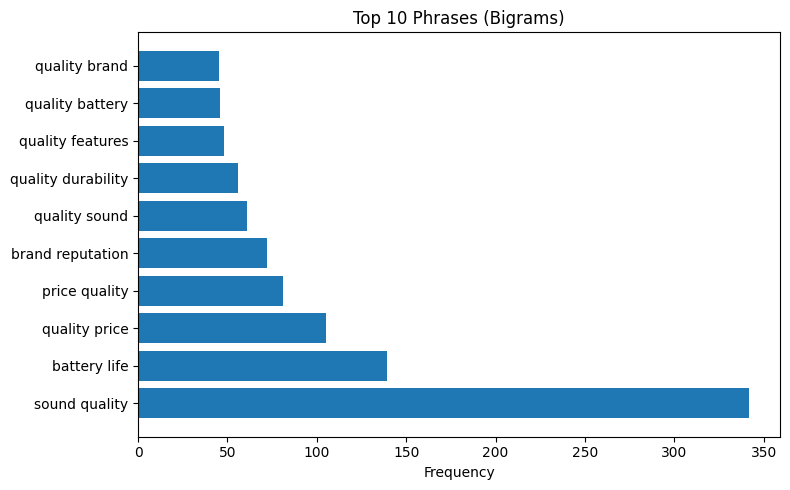

In [149]:
# visualise common phrase

common_bigrams = bigram_counts.most_common(10)

bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.figure(figsize=(8,5))
bars = plt.barh(bg_labels, bg_counts)

plt.xlabel("Frequency")
plt.title("Top 10 Phrases (Bigrams)")
plt.tight_layout()
plt.show()

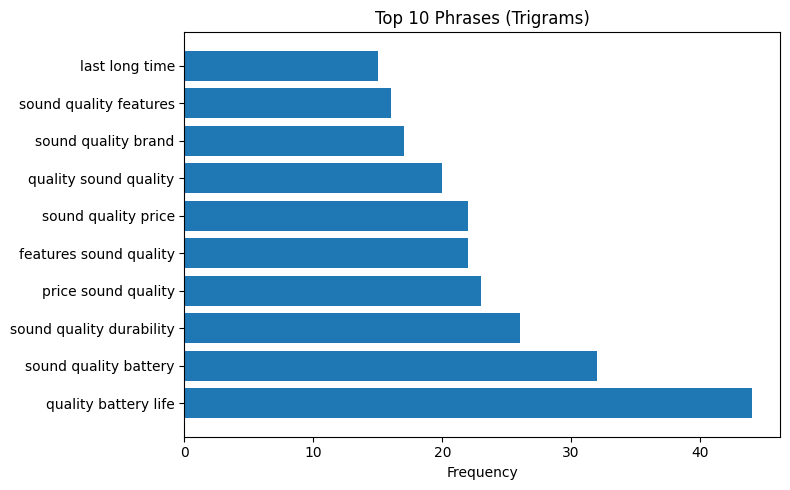

In [150]:
common_trigrams = trigram_counts.most_common(10)
tg_labels = [' '.join(tg) for tg, count in common_trigrams]
tg_counts = [count for tg, count in common_trigrams]

plt.figure(figsize=(8,5))
bars = plt.barh(tg_labels, tg_counts)

plt.xlabel("Frequency")
plt.title("Top 10 Phrases (Trigrams)")
plt.tight_layout()
plt.show()

Thematic Analysis

In [163]:
# score each respondent review in terms of facts and opinion.

df_users['text_for_sentiment'] = df_users['clean_tokens'].apply(lambda x: ' '.join(x))

In [167]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

x_tfidf = tfidf.fit_transform(df_users['text_for_sentiment'])

In [168]:
x_tfidf.shape

(3565, 584)

In [170]:
# apply model to extract  5 top themes.

n_topics = 5

nmf = NMF(n_components=n_topics,
            random_state=42,
            max_iter=300
)

nmf.fit(x_tfidf)

,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",300
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [171]:
# Get the vocabulary from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Function to display top words for each topic
def display_topics(model, feature_names, n_top_words=10):
    """Display the top words for each topic discovered by the model."""
    
    print("="*70)
    print(f"DISCOVERED TOPICS (Top {n_top_words} keywords per topic):")
    print("="*70)
    
    for topic_idx, topic in enumerate(model.components_):
        # Get the top N words for this topic
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"\nTopic {topic_idx + 1}: {', '.join(top_features)}")

# Display the topics
display_topics(nmf, feature_names, n_top_words=20)

DISCOVERED TOPICS (Top 20 keywords per topic):

Topic 1: quality, quality price, price quality, quality brand, quality sound, pay, quality durability, brand quality, quality features, quality product, sound quality, product, features quality, quality reviews, match, high, cheapest, high quality, cost, affordable

Topic 2: price, features, quality price, price quality, important, best, range, price range, budget, price features, wireless, reasonable, product, value, features price, affordable, brands, price important, evaluate, higher

Topic 3: reviews, online, online reviews, budget, prices, quality reviews, expert, expert reviews, check, reviews price, check reviews, customer, looking, brand reviews, customer reviews, reviews brand, reviews features, cheaper, brands, features

Topic 4: sound, sound quality, battery, life, battery life, durability, quality battery, features, quality sound, quality durability, design, size, life sound, long, brand sound, price sound, durability sound, c

Evaluating Discovered Topic

Thematic Coding Framework

Based on the topic modeling results, the following themes are defined:

- **Product Quality**
- **Budget**
- **Reviews**
- **Product Features**
- **Brand Reputation**

Using **Rule-based Coding** to systematically assign predefined thematic labels to reviews, transforming unstructured qualitative text into structured quantitative data that can be measured and compared across themes.

In [178]:
theme_codebook = {
    "Product Quality": [
        "high quality", "quality product", "quality sound", "quality brand",
        "quality durability", "quality features", "quality price", "quality reviews",
        "sound quality", "quality match", "high", "cost", "affordable", "cheapest",
        "pay", "product"
    ],

   "Budget": [
        "price range", "budget", "affordable", "reasonable", "price features",
        "price quality", "price important", "higher", "value", "best price",
        "wireless", "brands", "evaluate", "price", "important", "range"
    ], 

    "Reviews": [
        "online reviews", "expert reviews", "customer reviews", "check reviews",
        "brand reviews", "reviews brand", "reviews features", "reviews price",
        "quality reviews", "cheaper", "looking", "check", "budget",
        "prices", "brands"
    ],

    "Product Features": [
        "battery life", "sound quality", "quality durability", "quality battery",
        "quality sound", "features sound", "durability sound", "life sound",
        "brand sound", "price sound", "connectivity", "design", "size",
        "long", "consider", "durability", "battery", "features"
    ],

    "Brand Reputation": [
        "brand reputation", "reputable", "brand quality", "brand features",
        "brand sound", "brand reviews", "reviews brand", "depends brand",
        "reputation brand", "quality brand", "value", "prices",
        "depends", "product", "size", "durability", "features"
    ],

}

In [184]:
# function to apply theme code to surveys responses

def assign_themes(text, codebook):
    if not text:
        return [] # Return an empty list is text is missing.

    text = text.lower()
    matched_themes =[] # Empty list to store themes in text.

    for theme, keywords in codebook.items(): # Loop through the codebook dictionary 
        for kw in keywords: # Loop through every keyword for that theme.
            pattern = r"\b" + re.escape(kw).replace(r"\ ", r"\s+") + r"\b" 
            """Creates regex pattern to search for keywords, preventing partial matches, protect special characters & allows spacing"""
            if re.search(pattern, text): # Search for text for the keyword pattern.
                matched_themes.append(theme) # keywords are appended to the empty match_theme list
                break
    
    return matched_themes

In [185]:
df_users["matched_themes"] = df_users['text_for_sentiment'].apply(lambda x: assign_themes(x, theme_codebook))

In [186]:
df_users[['text_for_sentiment', 'matched_themes']].head(5)

,text_for_sentiment,matched_themes
0,better computer sound,[]
3,go cheaper,[Reviews]
4,usage,[]
5,price compared features sound quality size,"[Product Quality, Budget, Product Features, Br..."
6,price determined size importantly quality soun...,"[Product Quality, Budget, Product Features, Br..."


In [188]:
# Theme distributions amongst respondents

all_themes = [theme for themes_list in df_users['matched_themes'] for theme in themes_list] #flattens list of lists to extract each theme.
theme_counts = Counter(all_themes)

print("\n" + "="*50)
print("Theme Distribution:")
print("="*50)
for theme, count in theme_counts.most_common():
    print(f"{theme}: {count} reviews")


Theme Distribution:
Budget: 1414 reviews
Product Features: 1056 reviews
Brand Reputation: 1006 reviews
Product Quality: 866 reviews
Reviews: 543 reviews


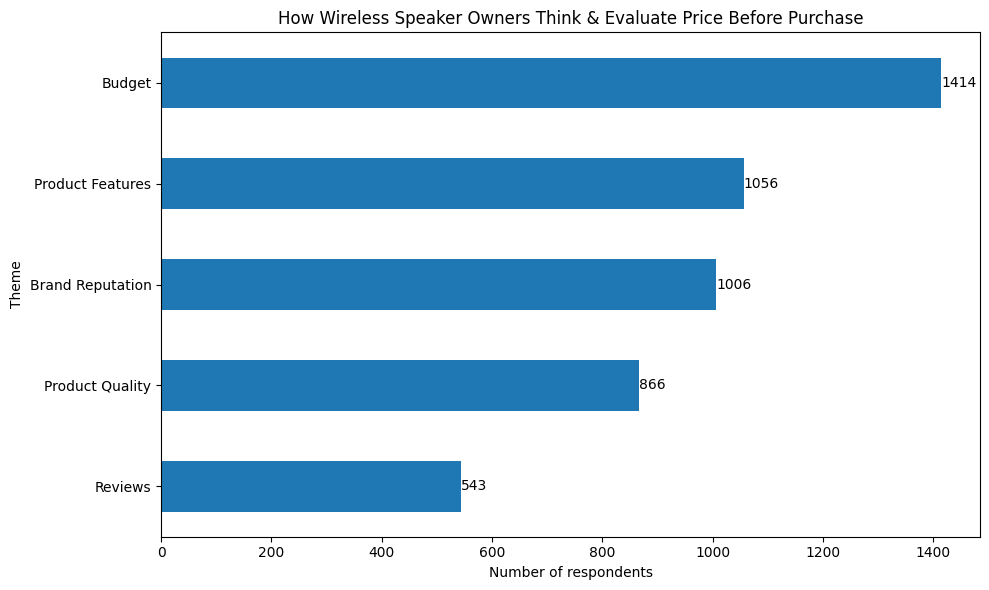

In [191]:
# Visualise the distribution 

theme_df = pd.DataFrame(theme_counts.most_common(), columns=['Theme', 'Count'])
theme_df = theme_df.sort_values('Count', ascending=True)

ax = theme_df.plot(
    x='Theme',
    y='Count',
    kind='barh',
    title='How Wireless Speaker Owners Think & Evaluate Price Before Purchase',
    xlabel='Number of respondents',
    legend=False,
    figsize=(10,6)
)

ax.bar_label(ax.containers[0], fmt="%.0f")

plt.tight_layout()
plt.show()

Segmentation Analysis

What does each age group feel or consider when evaluating price of wireless speakers?

In [195]:
df_users_exploded = df_users.explode("matched_themes") # split the themes into separate rows.

segment_theme_counts = (
    df_users_exploded.groupby(['age', 'matched_themes']) # count how many times each theme appears per segment.
    .size()
    .unstack(fill_value=0)
)

segment_total_counts = df_users['age'].value_counts()
segment_theme_counts['segment_total'] = segment_total_counts # add the total number in each segment to the table.

segment_theme_counts

matched_themes,Brand Reputation,Budget,Product Features,Product Quality,Reviews,segment_total
age,,,,,,
18-24,721,990,772,616,386,2445
25-34,192,235,189,163,96,646
35-44,30,61,33,29,17,147
45-54,22,48,21,25,20,121
55-64,8,19,10,3,5,50
65 and over,1,4,0,1,1,9
Under 18,32,57,31,29,18,147


In [196]:
# To understand the relative importance within each segment

segment_theme_pct = segment_theme_counts.div(
    segment_theme_counts["segment_total"], axis=0
) * 100

segment_theme_pct = segment_theme_pct.drop(columns='segment_total')

segment_theme_pct.round(1)

matched_themes,Brand Reputation,Budget,Product Features,Product Quality,Reviews
age,,,,,
18-24,29.5,40.5,31.6,25.2,15.8
25-34,29.7,36.4,29.3,25.2,14.9
35-44,20.4,41.5,22.4,19.7,11.6
45-54,18.2,39.7,17.4,20.7,16.5
55-64,16.0,38.0,20.0,6.0,10.0
65 and over,11.1,44.4,0.0,11.1,11.1
Under 18,21.8,38.8,21.1,19.7,12.2
